$$ ITI \space AI-Pro: \space Intake \space 45 $$
$$ Deep \space Learning $$
$$ Lab \space no. \space 1 $$

# `01` Assignment 01
- Design your own simple ANN,(one perceptron with one input layer
and one output neuron)
- Use the data points listed in the adjacent Table as your training data.
- Assume the activation function is sigmoid.
- Assume there is no bias for simplicity (b=0).
- Test your design using different iteration numbers.


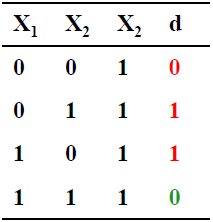

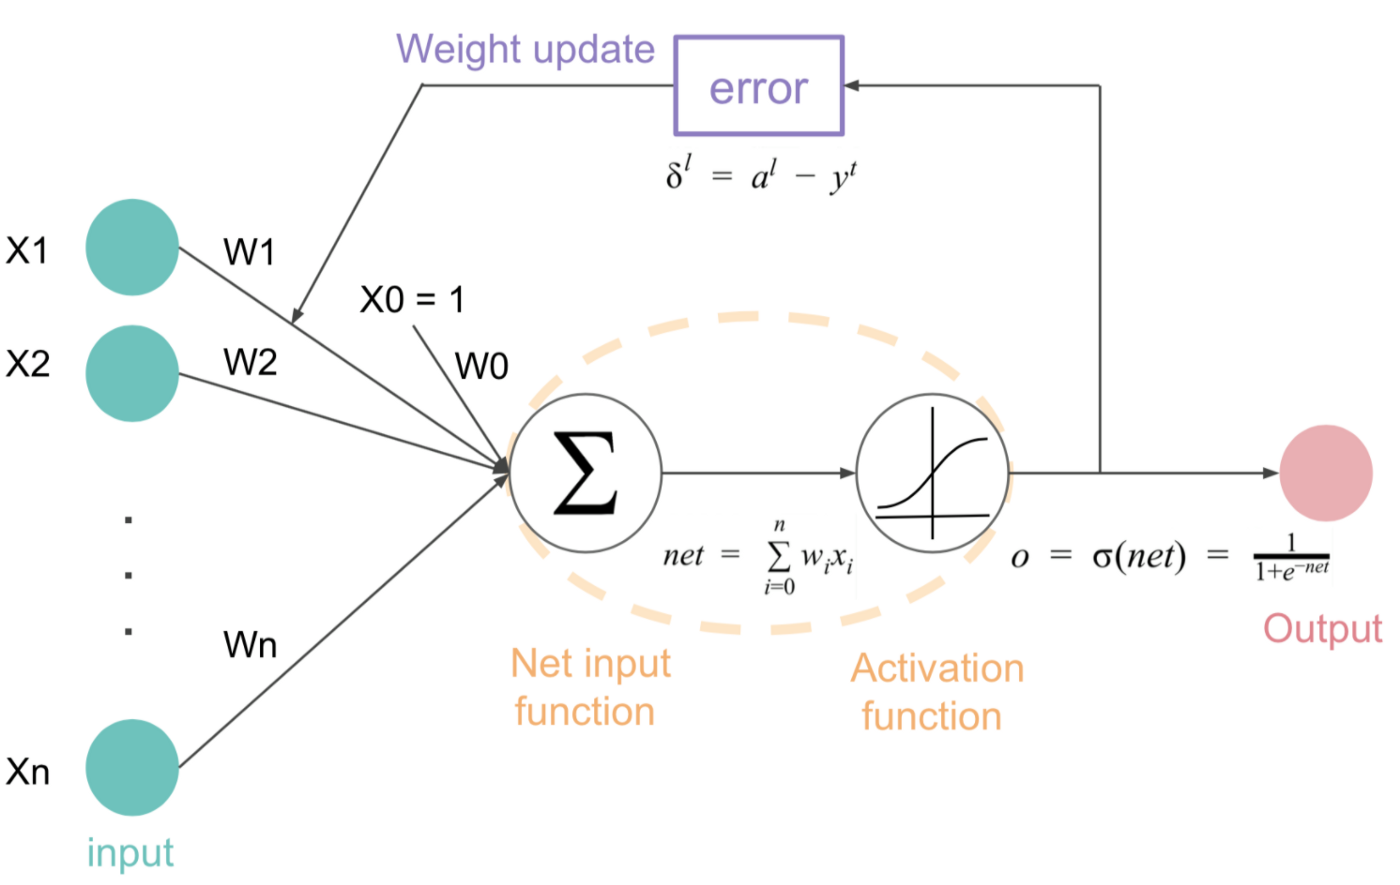

## `i` Implementation

In [1]:
import numpy as np
np.random.seed = 42

In [8]:
lr=0.001
class ANN:
    def __init__(self, X, y):
        self.X=X
        self.y=y
        self.w1=np.random.randn()
        self.w2=np.random.randn()
        self.w3=np.random.randn()

    def sigmoid(self, z):
        h=1 / (1 + np.exp(-z))
        return h

    def sigmoid_derivative(self, p):

        return p*(1-p)



    def feedforward(self):
        y=self.w1*self.X[:,0]+self.w2*self.X[:,1]+self.w3*self.X[:,2]
        y_hat=self.sigmoid(y)
        return y_hat



    def backprop(self):
        y_hat=self.feedforward()
        e=self.y-y_hat
        d_out=e*self.sigmoid_derivative(y_hat)
        self.w1=self.w1+lr*np.sum(d_out*self.X[:,0])
        self.w2=self.w2+lr*np.sum(d_out*self.X[:,1])
        self.w3=self.w3+lr*np.sum(d_out*self.X[:,2])
        loss = -np.mean(self.y * np.log(y_hat + 1e-8) + (1 - self.y) * np.log(1 - y_hat + 1e-8))
        return loss, y_hat


    def fit(self, iterations, verbose=1):
        for i in range(iterations):
          e,y_hat=self.backprop()
          print(f"Iteration {i} ==================================================")
          print("y_Actual: ")
          print(self.y)
          print("y_Predicted:")
          print(y_hat)
          print("loss:",e)









## `ii` Testing

In [9]:
X = np.array([
    [0, 0, 1],
    [1, 1, 1],
    [1, 0, 1],
    [0, 1, 1],
], dtype=float)


y = np.array([
    [0],
    [1],
    [1],
    [0],
], dtype=float)


print('X:\n', X, '\n')
print('y:\n', y)

X:
 [[0. 0. 1.]
 [1. 1. 1.]
 [1. 0. 1.]
 [0. 1. 1.]] 

y:
 [[0.]
 [1.]
 [1.]
 [0.]]


In [10]:
model = ANN(X, y)
model.fit(iterations=1000, verbose=1)

Streaming output truncated to the last 5000 lines.
 [1.]
 [0.]]
y_Predicted:
[0.63577395 0.46835848 0.87045268 0.18623925]
loss: 0.8653078308821605
Iteration 445 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.63575747 0.46836222 0.87042937 0.18626207]
loss: 0.8652743420296527
Iteration 446 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.635741   0.46836595 0.87040605 0.1862849 ]
loss: 0.8652408538478251
Iteration 447 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.63572452 0.46836967 0.87038273 0.18630773]
loss: 0.8652073663377924
Iteration 448 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.63570805 0.4683734  0.8703594  0.18633056]
loss: 0.8651738795006708
Iteration 449 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted

----

# `02` Assignment 02
- Modify the above designed code to implement a `multi layer perceptron`, `MLP` (an ANN with one input layer, one hidden layer and one output layer) for the same data points above
- Assume `sigmoid` activation function and there is `no bias` for simplicity (b=0)
- Test your approach using `different iteration numbers` and `different number of nodes` for the hidden layer (e.g. 4, 8 and 16)

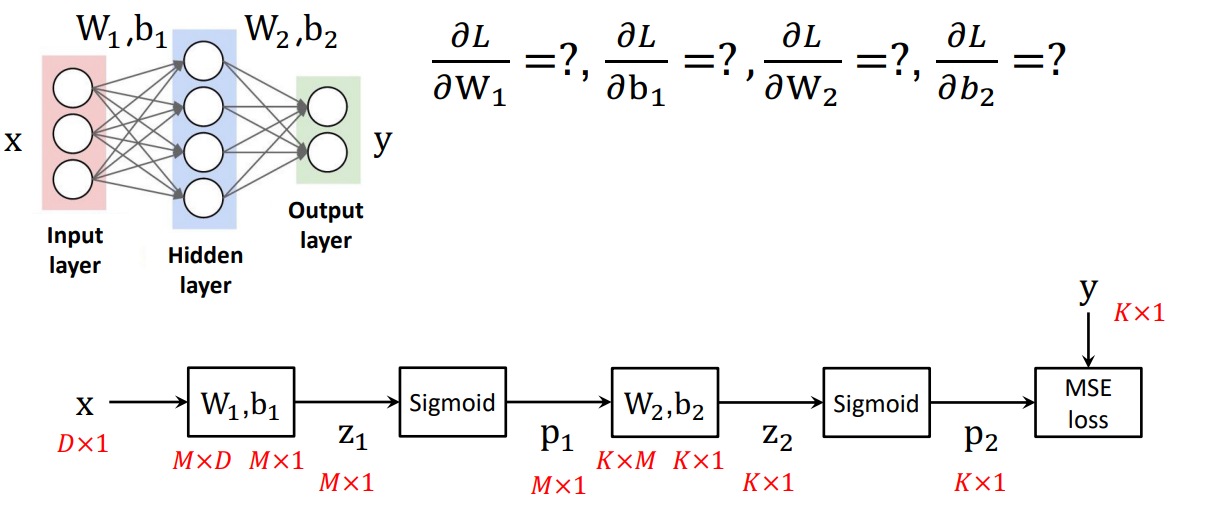

## `i` Implementation

In [11]:
class ANN:
    def __init__(self, X, y, num_hidden_nodes,lr=0.0001):
        self.X=X
        self.y=y
        self.num_hidden_nodes=num_hidden_nodes
        self.w11=np.random.randn()
        self.w12=np.random.randn()
        self.w21=np.random.randn()
        self.w22=np.random.randn()
        self.w31=np.random.randn()
        self.w32=np.random.randn()
        self.w_out1=np.random.randn()
        self.w_out2=np.random.randn()
        self.lr=lr


    def sigmoid(self, z):
        h=1 / (1 + np.exp(-z))
        return h

    def sigmoid_derivative(self, p):

        return p*(1-p)

    def feedforward(self):
        y1=self.w11*self.X[:,0]+self.w21*self.X[:,1]+self.w31*self.X[:,2]
        y2=self.w12*self.X[:,0]+self.w22*self.X[:,1]+self.w32*self.X[:,2]
        y1_hat=self.sigmoid(y1)
        y2_hat=self.sigmoid(y2)
        y_hat=self.w_out1*y1_hat+self.w_out2*y2_hat
        final_out=self.sigmoid(y_hat)
        return final_out, y1_hat, y2_hat

    def backprop(self):
      final_out, y1_hat, y2_hat=self.feedforward()
      e=self.y-final_out
      d_out=e*self.sigmoid_derivative(final_out)
      self.w_out1=self.w_out1+self.lr*np.sum(d_out*y1_hat)
      self.w_out2=self.w_out2+self.lr*np.sum(d_out*y2_hat)
      d_hidden1=d_out*self.w_out1*self.sigmoid_derivative(y1_hat)
      d_hidden2=d_out*self.w_out2*self.sigmoid_derivative(y2_hat)
      self.w11=self.w11+self.lr*np.sum(d_hidden1*X[:,0])
      self.w12=self.w12+self.lr*np.sum(d_hidden2*X[:,0])
      self.w21=self.w21+self.lr*np.sum(d_hidden1*X[:,1])
      self.w22=self.w22+self.lr*np.sum(d_hidden2*X[:,1])
      self.w31=self.w31+self.lr*np.sum(d_hidden1*X[:,2])
      self.w32=self.w32+self.lr*np.sum(d_hidden2*X[:,2])
      loss = -np.mean(self.y * np.log(final_out + 1e-8) + (1 - self.y) * np.log(1 - final_out + 1e-8))
      return loss, final_out


    def fit(self, iterations, verbose=1):
        for i in range(iterations):
          e,y_hat=self.backprop()
          print(f"Iteration {i} ==================================================")
          print("y_Actual: ")
          print(self.y)
          print("y_Predicted:")
          print(y_hat)
          print("loss:",e)

## `ii` Testing

In [12]:
X = np.array([
    [0, 0, 1],
    [1, 1, 1],
    [1, 0, 1],
    [0, 1, 1],
], dtype=float)


y = np.array([
    [0],
    [1],
    [1],
    [0],
], dtype=float)


print('X:\n', X, '\n')
print('y:\n', y)

X:
 [[0. 0. 1.]
 [1. 1. 1.]
 [1. 0. 1.]
 [0. 1. 1.]] 

y:
 [[0.]
 [1.]
 [1.]
 [0.]]


In [13]:
model = ANN(X, y, 2)
model.fit(iterations=1000, verbose=1)

Streaming output truncated to the last 5000 lines.
 [1.]
 [0.]]
y_Predicted:
[0.44626031 0.42902588 0.46548245 0.42359034]
loss: 0.7006949266712417
Iteration 445 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.44626332 0.42902884 0.46548558 0.42359326]
loss: 0.7006942108291361
Iteration 446 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.44626633 0.42903181 0.46548871 0.42359619]
loss: 0.7006934950622186
Iteration 447 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.44626934 0.42903477 0.46549184 0.42359911]
loss: 0.7006927793704811
Iteration 448 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted:
[0.44627235 0.42903774 0.46549497 0.42360204]
loss: 0.7006920637539158
Iteration 449 ==================================================
y_Actual: 
[[0.]
 [1.]
 [1.]
 [0.]]
y_Predicted

---

# `03` Assignment 03
- Use the `Keras` library tensorflow keras to build different ANNs using different numbers of hidden layers:
  - `shallow`  : 1 hidden, output layer
  - `deeper`   : two hidden layers with 12 and 8 nodes respectively
  - `more deep`: three hidden layers with 32 16 8 nodes respectively

Use the diabetic dataset provided [here](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database) to train and test your design Use the `ReLU` activation for the hidden layers and the `sigmoid` activation for the output neuron,
- `loss='binary_crossentropy'`
- `optimizer='adam'`
- `metrics=['accuracy’]`
- `epochs=150`

## `0` Import Libraries & Load Dataset

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

np.random.seed = 42

In [ ]:
dataset =pd.read_csv("/content/diabetes.csv")

In [ ]:
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
X =dataset.iloc[:,:-1]
y =dataset.iloc[:,-1]

In [ ]:
X.shape

(768, 8)

In [ ]:
y.shape

(768,)

## `i` Shallow network


In [ ]:
model=Sequential()
model.add(Dense(5, activation="relu", input_shape=(X.shape[1],)))
model.add(Dense(1, activation="sigmoid"))
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 5)                   │              45 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X.shape

(768, 8)

In [ ]:
768/32

24.0

In [ ]:
history = model.fit(X, y, epochs=150, batch_size=32)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3499 - loss: 48.6237   
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3475 - loss: 40.9152 
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3590 - loss: 35.7157 
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3530 - loss: 29.1608 
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3665 - loss: 22.1507 
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3585 - loss: 18.0311 
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4096 - loss: 10.0956 
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5299 - loss: 6.4669 
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6164 - loss: 4.7942 
Epoch 10/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6474 - loss: 3.7751 
Epoch 11/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5772 - loss: 3.9870 
Epoch 12/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
print(list(history.history.keys()))

['accuracy', 'loss']


In [ ]:
test_loss, test_accuracy = model.evaluate(X, y)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6968 - loss: 0.5832  


In [ ]:
test_loss, test_accuracy = model.evaluate(X, y)
print(f'Test accuracy: {test_accuracy}')

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6968 - loss: 0.5832 
Test accuracy: 0.7200520634651184


In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

Text(0, 0.5, 'accuracy')

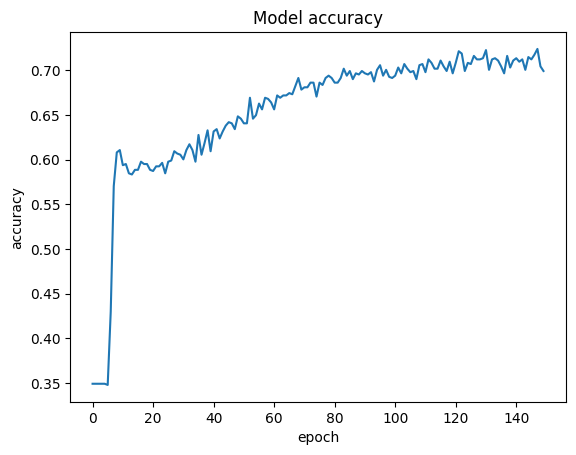

In [ ]:
plt.plot(history.history['accuracy'])
plt.title("Model accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')

Text(0, 0.5, 'loss')

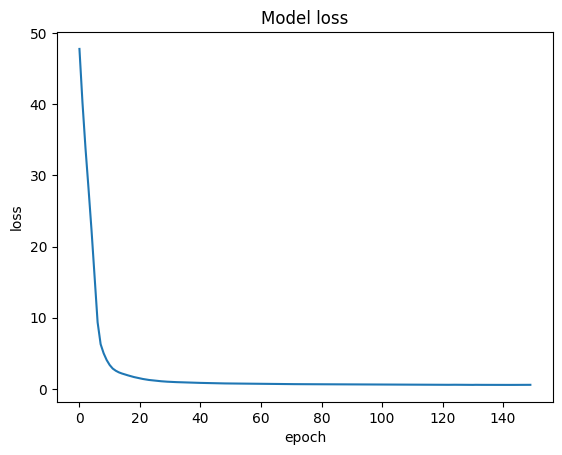

In [ ]:
plt.plot(history.history['loss'])
plt.title("Model loss")
plt.xlabel('epoch')
plt.ylabel('loss')

In [ ]:
model=Sequential()
model.add(Dense(5, activation="relu", input_shape=(X.shape[1],)))
model.add(Dense(12, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 5)                   │              45 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 12)                  │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 566 (2.21 KB)

 Trainable params: 566 (2.21 KB)

 Non-trainable params: 0 (0.00 B)

## `ii` Deep network


In [ ]:
history=model.fit(X,y,batch_size=32,epochs=150)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4234 - loss: 12.5884   
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6346 - loss: 3.5534 
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6318 - loss: 0.8756 
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5913 - loss: 0.7578 
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6507 - loss: 0.7272 
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5926 - loss: 0.7192 
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6453 - loss: 0.6742 
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6188 - loss: 0.6976 
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6409 - loss: 0.6635 
Epoch 10/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6512 - loss: 0.6717 
Epoch 11/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6255 - loss: 0.6894 
Epoch 12/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/st

In [ ]:
list(history.history.keys())

['accuracy', 'loss']

In [ ]:
loss,acc=model.evaluate(X,y)
print(loss,acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7353 - loss: 0.5426  
0.5138220191001892 0.7486979365348816


In [ ]:
loss,acc=model.evaluate(X,y)
print("Accuracy: ",acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7353 - loss: 0.5426 
Accuracy:  0.7486979365348816


Text(0, 0.5, 'accuracy')

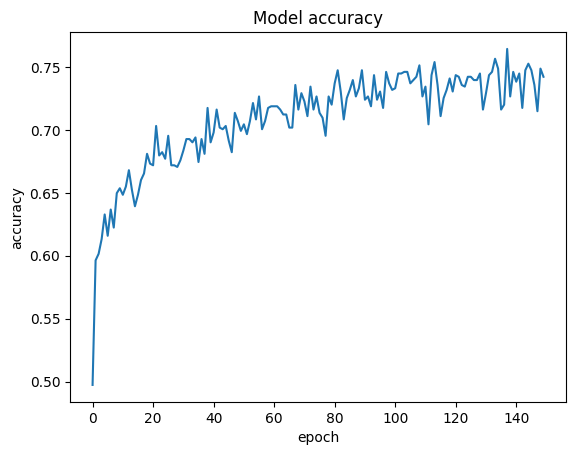

In [ ]:
plt.plot(history.history['accuracy'])
plt.title("Model accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')

Text(0, 0.5, 'loss')

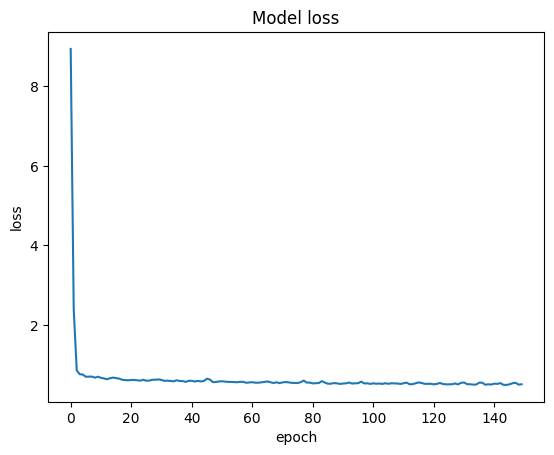

In [ ]:
plt.plot(history.history['loss'])
plt.title("Model loss")
plt.xlabel('epoch')
plt.ylabel('loss')

## `iii` Deeper network


In [ ]:
model=Sequential()
model.add(Dense(5, activation="relu", input_shape=(X.shape[1],)))
model.add(Dense(12, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                     │ (None, 5)                   │              45 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 12)                  │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 16)                  │             208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 902 (3.52 KB)

 Trainable params: 902 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X, y, epochs=150, batch_size=32)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3846 - loss: 5.1210
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5179 - loss: 1.3239 
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5518 - loss: 0.7806 
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6316 - loss: 0.6787 
Epoch 5/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6476 - loss: 0.6529 
Epoch 6/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6374 - loss: 0.6522 
Epoch 7/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6531 - loss: 0.6408 
Epoch 8/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6421 - loss: 0.6745 
Epoch 9/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6587 - loss: 0.6533 
Epoch 10/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6530 - loss: 0.6652 
Epoch 11/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6519 - loss: 0.6312 
Epoch 12/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

In [ ]:
list(history.history.keys())

['accuracy', 'loss']

In [ ]:
loss,acc=model.evaluate(X,y)
print(acc,loss)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7260 - loss: 0.5178 
0.7630208134651184 0.47610700130462646


In [ ]:
loss,acc=model.evaluate(X,y)
print("Accuracy: ",acc)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7260 - loss: 0.5178 
Accuracy:  0.7630208134651184


Text(0, 0.5, 'accuracy')

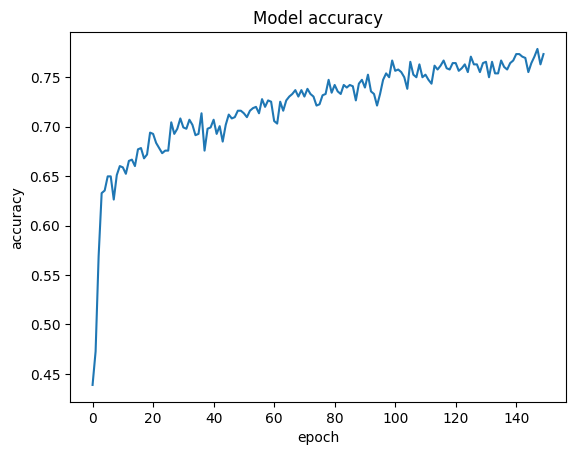

In [ ]:
plt.plot(history.history['accuracy'])
plt.title("Model accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')

Text(0, 0.5, 'loss')

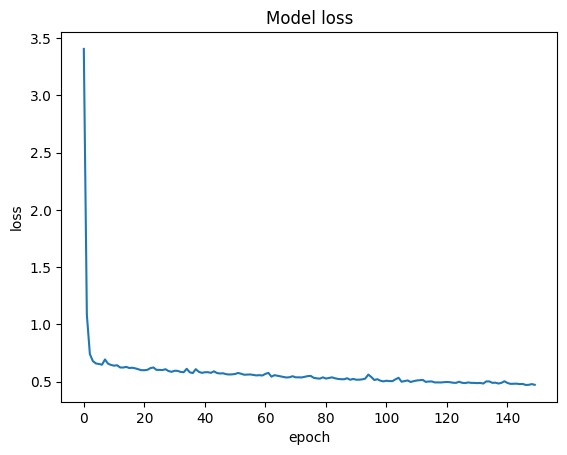

In [ ]:
plt.plot(history.history['loss'])
plt.title("Model loss")
plt.xlabel('epoch')
plt.ylabel('loss')

----------------------------------------------

$$ Wish \space you \space all \space the \space best \space ♡ $$
$$ Abdelrahman \space Eid $$